# P1 — GT gallery: RGB / real IR / mask / predicted IR / normalized signals

**Input**: one hand-annotated ground-truth (GT) painting, chosen among the images under `data/test/` that have a matching mask (`data/test/annotations/<stem>_Map.png`) — its RGB photograph, real infrared (IR) photograph, and binary hidden-detail mask; plus one trained heteroscedastic (NLL) RGB→IR architecture, chosen among the checkpoints under `models/nll/`.

**Output**: a single 2×3 figure —
- **row 1**: RGB, real IR, ground-truth mask, each on its natural scale.
- **row 2**: the selected model's predicted mean IR (`mu`), and its two sigma-normalized hidden-detail signals — `|z|` and structural z — each independently percentile-clipped so a handful of outlier pixels don't flatten the rest.

**Model**: a heteroscedastic architecture predicts two channels per pixel — a mean IR value `mu` and a Laplace log-scale `log_b` — trained with a Laplace negative-log-likelihood loss. Standard deviation: `sigma = exp(log_b) · √2` (the Laplace formula, not the Gaussian `exp(0.5·log_var)`).

**Signals**:
- **`|z|`** `= |real_IR − mu| / sigma` — the raw pixel-wise error normalized by the model's own predicted uncertainty.
- **structural z** `= structural_delta / smoothed(sigma)`, where `structural_delta = 1 − S` isolates the local *structure* term `S` of the Structural Similarity Index (SSIM), computed on an 11×11 Gaussian window (σ = 1.5) — the same window `tf.image.ssim` uses (Wang, Bovik, Sheikh, Simoncelli, "Image Quality Assessment: From Error Visibility to Structural Similarity," *IEEE Trans. Image Processing*, 2004). `sigma` is Gaussian-smoothed with the same window before dividing, so a windowed quantity is not combined with a raw per-pixel one.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [13]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check.


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import laplace_sigma_from_scale, learned_zscore, structural_zscore
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import compute_local_stats, compute_ssim_components
from scripts.trainer_nll import load_model_nll

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Choose the ground-truth image

Discovered generically from `data/test/annotations/*_Map.png` — any pair with a matching mask is picked up automatically. Set `GT_STEM` to one of the printed stems.


In [15]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"
MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges

mask_paths = sorted(ANNOTATIONS_DIR.glob("*_Map.png")) if ANNOTATIONS_DIR.exists() else []
available_stems = []
for mask_path in mask_paths:
    stem = mask_path.name.removesuffix("_Map.png")
    rgb_path, ir_path = TEST_RGB_DIR / f"{stem}.jpg", TEST_IR_DIR / f"{stem}.jpg"
    if rgb_path.exists() and ir_path.exists():
        available_stems.append(stem)

print(f"Available ground-truth images: {available_stems}")
if not available_stems:
    raise RuntimeError("No ground-truth (rgb, ir, mask) triplet found under data/test/.")

GT_STEM = available_stems[1]  # e.g. "GT01" — set to any stem printed above

if GT_STEM not in available_stems:
    raise ValueError(f"GT_STEM={GT_STEM!r} not among {available_stems}.")

print(f"Selected: {GT_STEM}")

Available ground-truth images: ['GT01', 'GT02', 'GT03']
Selected: GT02


## 2. Choose the NLL model

Every heteroscedastic architecture trained in the project, loading its single Laplace-NLL checkpoint from `models/nll/<arch>/`. Set `MU_ARCH` to any of the printed names.


In [16]:
NLL_ARCHS = [
    #"unet_nll",
    #"resunet_nll",
    "attention_unet_nll",
    #"efficientnet_unet_nll",
    #"efficientnet_unet_nll_ft",
]
BETA = settings.NLL_BETA

print(f"Available NLL architectures: {NLL_ARCHS}")

MU_ARCH = "attention_unet_nll"  # set to any architecture printed above

if MU_ARCH not in NLL_ARCHS:
    raise ValueError(f"MU_ARCH={MU_ARCH!r} not among {NLL_ARCHS}.")

model = load_model_nll(
    MU_ARCH, model_dir=settings.MODELS_DIR / "nll", loss_name="laplace_nll", beta=BETA
)
print(f"Loaded: {MU_ARCH}")

Available NLL architectures: ['attention_unet_nll']
Loaded: attention_unet_nll


## 3. Predict and build the normalized signals

Runs the selected model on the selected image once, then builds `mu`, `sigma`, `|z|`, and structural z from that single prediction.


In [17]:
def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load an ``(rgb, ir)`` pair as float arrays in ``[0, 1]``."""
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


def load_mask(stem: str) -> np.ndarray:
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def structural_delta_map(ir: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """``1 - local SSIM structure`` between the real and predicted IR."""
    stats = compute_local_stats(ir, mu)
    return 1.0 - compute_ssim_components(stats).structure


rgb, ir = load_pair(TEST_RGB_DIR / f"{GT_STEM}.jpg", TEST_IR_DIR / f"{GT_STEM}.jpg")
mask = load_mask(GT_STEM)

padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
h, w = ir.shape
pred = model.predict(padded[tf.newaxis, ...], verbose=0)[0, :h, :w, :]

mu = pred[..., 0]
sigma = laplace_sigma_from_scale(np.exp(pred[..., 1]))
structural_delta = structural_delta_map(ir, mu)

z = np.abs(learned_zscore(ir, mu, sigma))
struct_z = structural_zscore(structural_delta, sigma)

print(f"{MU_ARCH} on {GT_STEM}: mu/sigma/|z|/structural_z built, shape {mu.shape}")

attention_unet_nll on GT02: mu/sigma/|z|/structural_z built, shape (1300, 1205)


## 4. The 2×3 gallery

RGB / real IR / ground-truth mask on their natural scale (row 1), then predicted IR / `|z|` / structural z (row 2), each independently percentile-clipped to its own `[0, p99]` range and labeled with that range in its title — no colorbar, so the panel is read for shape and location, not for the literal pixel value.


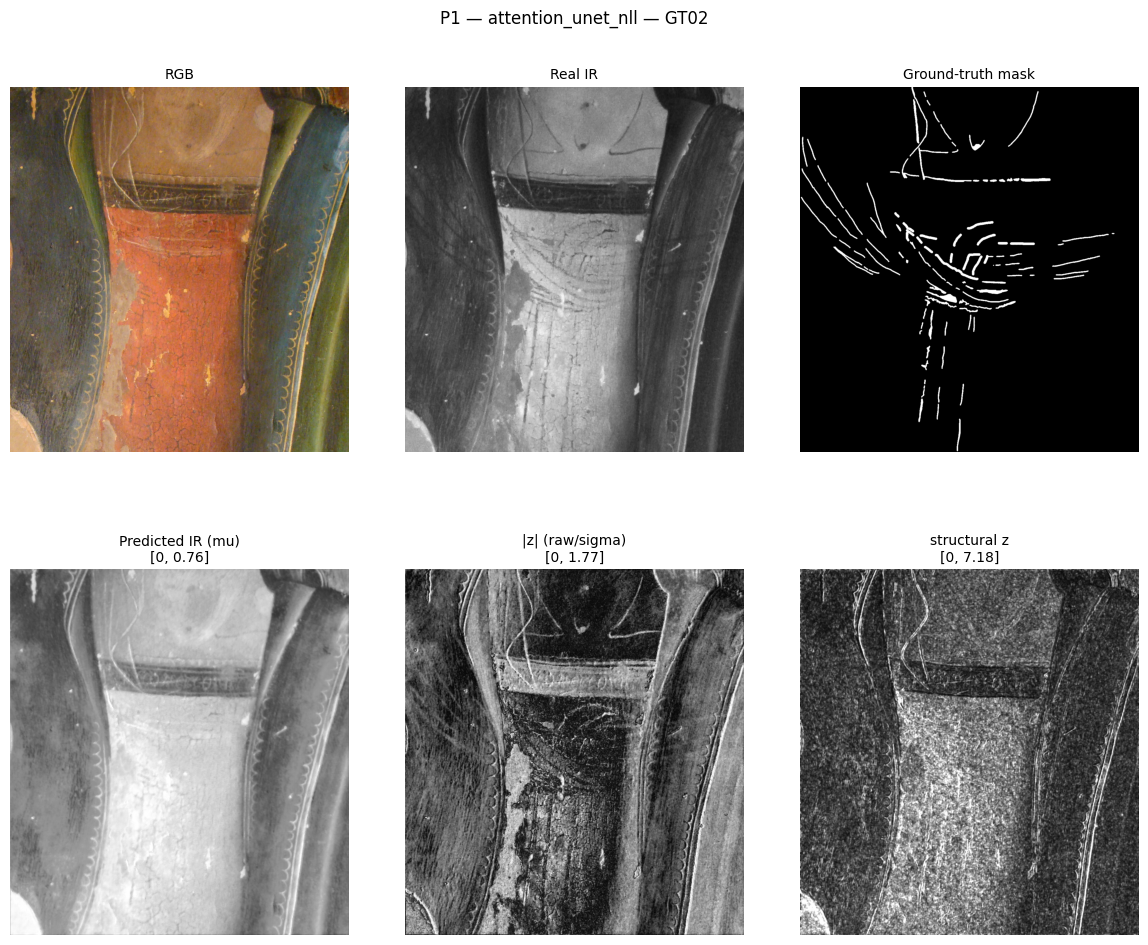

In [18]:
def plot_gallery_no_colorbar(
    rgb: np.ndarray,
    ir_real: np.ndarray,
    mask: np.ndarray,
    signals: dict[str, np.ndarray],
    title: str = "",
    percentile: float = 99.0,
) -> plt.Figure:
    """RGB / real IR / mask (row 1) + 3 signal panels (row 2), no colorbars.

    Each signal panel is independently clipped to ``[0, percentile]`` of its
    own values, same construction as ``scripts.visualization.plot_gt_signal_gallery``,
    but the display range is stated only in the panel title (no gradient
    scale bar) so the figure reads for shape, not for the literal value.
    """
    panels = [
        ("RGB", rgb, None, "viridis"),
        ("Real IR", ir_real.squeeze(), (0.0, 1.0), "gray"),
        ("Ground-truth mask", mask.squeeze().astype(float), (0.0, 1.0), "gray"),
    ]
    for name, data in signals.items():
        arr = data.squeeze()
        vmax = float(np.percentile(np.abs(arr), percentile))
        if vmax <= 1e-8:
            vmax = float(np.abs(arr).max()) + 1e-8
        panels.append((name, arr, (0.0, vmax), "gray"))

    fig, axes = plt.subplots(2, 3, figsize=(12, 9.5))
    fig.suptitle(title, y=0.99)
    for ax, (panel_title, data, vrange, cmap) in zip(axes.flat, panels):
        if vrange is None:
            ax.imshow(data)
            ax.set_title(panel_title, fontsize=10)
        else:
            vmin, vmax = vrange
            ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
            label = (
                panel_title
                if panel_title in ("Real IR", "Ground-truth mask")
                else f"{panel_title}\n[0, {vmax:.2f}]"
            )
            ax.set_title(label, fontsize=10)
        ax.axis("off")
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    fig.subplots_adjust(hspace=0.32)
    return fig


signals = {
    "Predicted IR (mu)": mu,
    "|z| (raw/sigma)": z,
    "structural z": struct_z,
}

fig = plot_gallery_no_colorbar(
    rgb, ir, mask, signals, title=f"P1 — {MU_ARCH} — {GT_STEM}"
)
plt.show()